# Idea: Propose–Verify–Correct
1. Answerer:
   Prompt the VLM to answer the question given the flowchart.

2. Verifier:
   Given the flowchart, question, and proposed answer, prompt the VLM to:
   - determine whether the answer is derivable from the flowchart,
   - output a binary decision (YES / NO),
   - provide a grounding-based reason referencing specific flowchart content.

   If the decision is NO, the verifier must also produce a corrected answer
   that is derivable from the flowchart.

3. Final Answer:
   If YES, return the original answer.
   If NO, return the corrected answer.


# Experiment
1. Try with a few samples
2. Evaluate dev score

In [16]:
# Helper functions
import base64
import os
import random
from typing import List
from PIL import Image
from openai import OpenAI
import pandas as pd
import json
from IPython.display import display, HTML


VLM_MODEL_ID = "openai/gpt-5.1-chat"
LLM_MODEL_ID = "openai/gpt-5.1-chat"
openai_client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=os.environ["OPENROUTER_API_KEY"])

# Load FlowVQA dev set JSON
with open("../data/flowvqa/dev.json", "r") as f:
    flowvqa_dev_set = json.load(f)

# Form a Pandas DataFrame
records = []
index = []
for k, v in flowvqa_dev_set.items():                
    for question_id, qa in v["qa"].items():
        answers = [qa["A1"], qa["A2"], qa["A3"]]
        records.append({
            "question_id": question_id,
            "question": qa["Q"],
            "answers": answers,
            "type": qa["type"]
        })
        index.append(k)
flowvqa_dev_df = pd.DataFrame(records, index=index)


'''
Sample 5 flowcharts from FlowVQA dev set for smoke test, with the constraint that:
    - 1 code flowchart
    - 1 wiki flowchart
    - 1 instruct flowchart
    - 2 randomly sampled flowcharts
Inputs:
    - boolean indicating whether to display the sampled flowcharts
    - random seed
    - maximum width or height for display (pixels)
Outputs:
    - list of sampled flowchart names
'''
def sample_5_flowcharts(
    display_flowchart: bool = False,
    seed: int | None = None
) -> List[str]:
    if seed is not None:
        random.seed(seed)  

    flowchart_names = list(flowvqa_dev_set.keys())

    code_flowchart = None
    instruct_flowchart = None
    wiki_flowchart = None
    for x in flowchart_names:
        if (not code_flowchart) and x.startswith("code"):
            code_flowchart = x
        elif (not instruct_flowchart) and x.startswith("instruct"):
            instruct_flowchart = x
        elif (not wiki_flowchart) and x.startswith("wiki"):
            wiki_flowchart = x
        if code_flowchart and instruct_flowchart and wiki_flowchart:
            break

    flowchart_names.remove(code_flowchart)
    flowchart_names.remove(instruct_flowchart)
    flowchart_names.remove(wiki_flowchart)
    random_samples = random.sample(flowchart_names, 2)
    sampled_flowcharts = [code_flowchart, instruct_flowchart, wiki_flowchart] + random_samples

    if display_flowchart:
        for p in sampled_flowcharts:
            # clear visual separation
            display(HTML("<hr style='margin:16px 0'>"))
            
            # show filename / context
            display(HTML(f"<div style='font-family:monospace;opacity:0.7'>{p}</div>"))
            
            # load and shrink image to avoid huge output
            img = Image.open(os.path.join("/app/data/flowvqa/images/", p + ".png"))
            img.thumbnail((400, 400))
            display(img)
            
    return sampled_flowcharts


'''
Query the VLM with image and a text prompt.
Inputs:
    - image file path
    - text prompt
Outputs:
    - response by the VLM
'''
def query_VLM(image_path, prompt, max_new_tokens=4096, temperature=0.0):
    # encode as base64 binary
    with open(image_path, "rb") as image_file:
        image =  base64.b64encode(image_file.read()).decode("utf-8")

    messages = [
                {"role": "system", "content": "You are a helpful assistant."},
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/jpeg;base64,{image}",
                                "detail": "high",
                            },
                        },
                    ],
                },
            ]

    completion = openai_client.chat.completions.create(
        model=VLM_MODEL_ID,
        max_tokens=max_new_tokens,
        temperature=temperature,
        messages=messages,
        extra_body={"provider": {"only": ["openai"]}},
    )
    
    response = completion.choices[0].message.content
    return response


'''
Query the LLM with a text prompt.
Inputs:
    - text prompt
Outputs:
    - response by the LLM
'''
def query_LLM(prompt, max_new_tokens=4096, temperature=0.0):
    messages = [
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": prompt},
            ]

    completion = openai_client.chat.completions.create(
        model=LLM_MODEL_ID,
        max_tokens=max_new_tokens,
        temperature=temperature,
        messages=messages,
        extra_body={"provider": {"only": ["openai"]}},
    )
    
    response = completion.choices[0].message.content
    return response

## View dataset

In [17]:
flowvqa_dev_df

,question_id,question,answers,type
wiki00071,1,What book should be read for a humorous take o...,"['Zhuangzi Speaks' and 'The Tao Speaks', Read ...",fact_retrieval
wiki00071,2,What should one seek when searching for transl...,"[Quality and accuracy, Translations with high ...",fact_retrieval
wiki00071,3,Assuming I'm at the step where I'm comparing t...,[The immediate next steps would be 'Use the se...,flow_referential
wiki00071,4,How many nodes exist in the given flowchart?,"[25, There are twenty-five nodes in the flowch...",topological
wiki00071,5,How many edges exist in the given flowchart?,"[29, There are twenty-nine edges in the flowch...",topological
...,...,...,...,...
instruct00811,6,Assuming I am currently at the step where I am...,"[If difficulty is encountered, the next step w...",flow_referential
instruct00811,7,How many nodes exist in the given flowchart?,"[22, There are twenty-two nodes in the flowcha...",topological
instruct00811,8,How many edges exist in the given flowchart?,"[25, There are twenty-five edges in the flowch...",topological
instruct00811,9,How many edges exist in the shortest path betw...,"[2, There are two edges in the shortest path b...",topological


In [18]:
print("Number of flowcharts:", len(set(flowvqa_dev_df.index)))
print("Number of qns:", len(flowvqa_dev_df))

Number of flowcharts: 13
Number of qns: 116


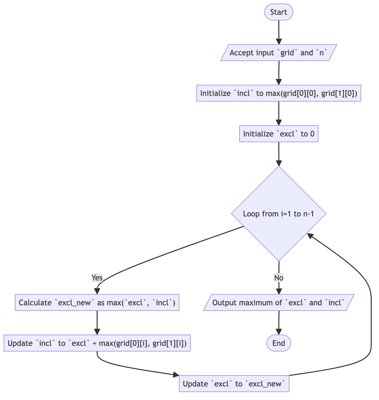

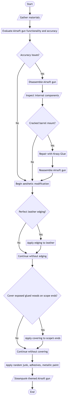

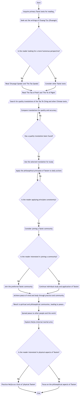

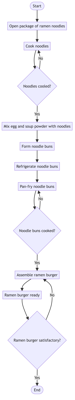

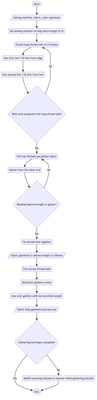

['code00268', 'instruct00856', 'wiki00071', 'instruct00665', 'instruct00286']

In [19]:
sample_5_flowcharts(True, 888)

## Implement idea

In [20]:
import json, re


def step1(question, flowchart_name):
    prompt_template = ("# Task\n"
                       "Based on the flowchart given in the image, please answer a question.\n"
                       "    Question: {question}\n\n"
                       " # Output format\n"
                       "Please only give your answer and nothing else. No explanations needed")
    return query_VLM(
        os.path.join("/app/data/flowvqa/images/", flowchart_name + ".png"),
        prompt_template.format(question=question)
    )


def step2(question, flowchart_name, step1_answer):
    prompt_template = '''# Task
Based on the flowchart given in the image and a question regarding the flowchart, please verify if an answer is derivable from the flowchart.
    Question: {question}
    Answer: {answer}

# Output format
Please output a binary decision "YES" or "NO", together with a reason for the decision that is grounded on specific flowchart structures or contents.
Additionally, if the decision is "NO", you **MUST** output the corrected answer as a separate last sentence.
Concretely, you must output with a single JSON object and nothing else:
{{
    "decision": "YES" | "NO",
    "explanation": "1–3 sentences explaining your decision that is grounded on the flowchart's contents or structures",
    "corrected_answer": "the corrected answer" # only include this field if decision is "NO"
}}'''

    return query_VLM(
        os.path.join("/app/data/flowvqa/images/", flowchart_name + ".png"),
        prompt_template.format(question=question, answer=step1_answer)
    )


_JSON_FENCE = re.compile(r"```(?:json)?\s*([\s\S]*?)\s*```", re.IGNORECASE)
_FIRST_OBJECT = re.compile(r"\{[\s\S]*\}")
_FIRST_ARRAY = re.compile(r"\[[\s\S]*\]")

def parse_llm_json(text):
    candidates: list[str] = []

    candidates.append(text)

    m = _JSON_FENCE.search(text)
    if m:
        candidates.append(m.group(1))

    m = _FIRST_OBJECT.search(text)
    if m:
        candidates.append(m.group(0))

    m = _FIRST_ARRAY.search(text)
    if m:
        candidates.append(m.group(0))

    for s in candidates:
        s = s.strip()
        if not s:
            continue
        try:
            return json.loads(s)
        except json.JSONDecodeError:
            pass

    return None


def flowchart_vqa(question, flowchart_name, verbose=False):
    step1_answer = step1(question, flowchart_name)
    
    if verbose:
        print("Step 1 answer:", step1_answer)
        print()

    max_tries = 10
    step2_obj = None

    for attempt in range(1, max_tries + 1):
        step2_response = step2(question, flowchart_name, step1_answer)

        step2_obj = parse_llm_json(step2_response)
        if step2_obj is not None:
            break

        if verbose:
            print(f"\n[Attempt {attempt}/{max_tries} of step 2] JSON parse failed.")
            print("Raw LLM response:")
            print("-" * 80)
            print(step2_response)
            print("-" * 80)

    if step2_obj is None:
        raise ValueError(
            f"Failed to parse valid JSON from step 2 LLM output after {max_tries} attempts."
        )
    
    if verbose:
        print("Step 2 parsed JSON:")
        print("-" * 80)
        print(json.dumps(step2_obj, indent=4))
        print("-" * 80)
        
    if step2_obj["decision"].upper() == "YES":
        return step1_answer

    return step2_obj["corrected_answer"]        

## Smoke test
- some mistakes with topological questions

In [42]:
flowchart_name = "code00268"
for _, row in flowvqa_dev_df.loc[flowchart_name].iterrows():
    qn = row["question"]
    gt = row["answer"]
    answer = flowchart_vqa(qn, flowchart_name)
    print("Question:", qn)
    print("Pipeline answer:", answer)
    print("GT:", gt)
    print("-" * 80)

Question: How is the initial value of 'incl' determined?
Pipeline answer: max(grid[0][0], grid[1][0])
GT: It is the maximum value of the first column of the grid.
--------------------------------------------------------------------------------
Question: Imagine you are writing a program to process a grid of numbers for a game. You've just initialized two variables, `incl` and `excl`, and you're about to enter a loop that starts with `i=1`. In this loop, you need to update a variable `excl_new`. Based on the algorithm you're following, what value should `excl_new` be assigned?
Pipeline answer: max(excl, incl)
GT: The maximum of `excl` and `incl`.
--------------------------------------------------------------------------------
Question: As you continue to iterate through the grid in your number-crunching application, you find yourself updating two variables, `incl` and `excl`, at each step. Once you have calculated the new value for `incl`, which involves adding the maximum of grid[0][i]

In [48]:
flowchart_name = "instruct00856"
for _, row in flowvqa_dev_df.loc[flowchart_name].iterrows():
    qn = row["question"]
    gt = row["answer"]
    answer = flowchart_vqa(qn, flowchart_name)
    print("Question:", qn)
    print("Pipeline answer:", answer)
    print("GT:", gt)
    print("-" * 80)

Question: What should be done if there are accuracy issues with the Airsoft gun?
Pipeline answer: Disassemble Airsoft gun
GT: Disassemble the Airsoft gun
--------------------------------------------------------------------------------
Question: How should a cracked barrel mount on the Airsoft gun be repaired?
Pipeline answer: Repair with Krazy Glue
GT: Repair it with Krazy Glue
--------------------------------------------------------------------------------
Question: Liam is customizing an Airsoft gun to fit a Steampunk theme for his short film, but he's having trouble giving the leather pieces a finished look with perfect edging. If he can't figure out how to edge the leather properly, what should he do to keep the project moving forward?
Pipeline answer: Continue without edging
GT: Continue the modification process without edging the leather.
--------------------------------------------------------------------------------
Question: Assuming the Airsoft gun has been disassembled due t

In [49]:
flowchart_name = "wiki00071"
for _, row in flowvqa_dev_df.loc[flowchart_name].iterrows():
    qn = row["question"]
    gt = row["answer"]
    answer = flowchart_vqa(qn, flowchart_name)
    print("Question:", qn)
    print("Pipeline answer:", answer)
    print("GT:", gt)
    print("-" * 80)

Question: What book should be read for a humorous take on Taoist philosophy?
Pipeline answer: Zhuangzi Speaks and The Tao Speaks
GT: 'Zhuangzi Speaks' and 'The Tao Speaks'
--------------------------------------------------------------------------------
Question: What should one seek when searching for translations of the Tao Te Ching?
Pipeline answer: Quality translations.
GT: Quality and accuracy
--------------------------------------------------------------------------------
Question: Assuming I'm at the step where I'm comparing translations for quality and accuracy, and I eventually find a quality translation, what are the immediate next two steps in the process?
Pipeline answer: Use the selected translation for study; Apply the philosophical principles of Taoism to daily actions
GT: The immediate next steps would be 'Use the selected translation for study' followed by 'Apply the philosophical principles of Taoism to daily actions'.
--------------------------------------------------

In [50]:
flowchart_name = "instruct00665"
for _, row in flowvqa_dev_df.loc[flowchart_name].iterrows():
    qn = row["question"]
    gt = row["answer"]
    answer = flowchart_vqa(qn, flowchart_name)
    print("Question:", qn)
    print("Pipeline answer:", answer)
    print("GT:", gt)
    print("-" * 80)

Question: After mixing the egg and soup powder with noodles, what is the next step?
Pipeline answer: Form noodle buns
GT: Form noodle buns
--------------------------------------------------------------------------------
Question: Leo is preparing to make ramen burgers for his food blog and wants to capture every detail of the process. After boiling the noodles, what critical step should he document next to ensure the noodles are ready for the subsequent stages?
Pipeline answer: Cool the noodles.
GT: Leo should document the cooling of the noodles, which is critical before mixing them with egg and soup powder.
--------------------------------------------------------------------------------
Question: If I'm currently at the step where I need to refrigerate noodle buns, what was the immediate previous step and what is the next step?
Pipeline answer: Form noodle buns; Pan-fry noodle buns
GT: The immediate previous step was forming noodle buns, and the next step is to pan-fry the noodle buns

In [51]:
flowchart_name = "instruct00286"
for _, row in flowvqa_dev_df.loc[flowchart_name].iterrows():
    qn = row["question"]
    gt = row["answer"]
    answer = flowchart_vqa(qn, flowchart_name)
    print("Question:", qn)
    print("Pipeline answer:", answer)
    print("GT:", gt)
    print("-" * 80)

Question: What stitch length should be set on the sewing machine for gathering fabric?
Pipeline answer: 3–4
GT: A long stitch length of 3-4
--------------------------------------------------------------------------------
Question: How far from the edge should the first line of stitching be when gathering fabric?
Pipeline answer: 1/8 inch
GT: 1/8 inch from the edge
--------------------------------------------------------------------------------
Question: What is the final step to secure the gathers in the fabric?
Pipeline answer: Sew over gathers with normal stitch length
GT: Sew over the gathers with a normal stitch length
--------------------------------------------------------------------------------
Question: Liam has gathered his fabric to the correct fullness and has secured the gathers by tying the thread tails. However, he's unsure if he should cut off the excess thread right away. What is the next step he should take according to the instructions?
Pipeline answer: Trim excess t

# Dev score

## Generate results JSON

In [9]:
from tqdm.notebook import tqdm_notebook

inference_obj = {}
for i, (index, row) in tqdm_notebook(enumerate(flowvqa_dev_df.iterrows()), total=len(flowvqa_dev_df)):
    question = row["question"]
    flowchart_name = str(index)
    inference_obj[str(i)] = {
        "key": flowchart_name,
        "question_id": row["question_id"],
        "question": question,
        "response": flowchart_vqa(question, flowchart_name),
        "answer":row["answer"]
    }

outfile = "../output/flowvqa/idea1"
with open(outfile, "w") as f:
    json.dump(inference_obj, f, indent=4)

print(f"Inference results saved to {outfile}!")

  0%|          | 0/116 [00:00<?, ?it/s]

Inference results saved to idea1.json!


In [21]:
%%bash
mkdir -p ../output/flowvqa/idea1
cp idea1.json ../output/flowvqa/idea1/gpt-5.1-chat.json
cd ../
python src/evaluation.py --model_names "${JUDGE_MODELS}" --data_path "output/flowvqa/idea1/gpt-5.1-chat.json"

2026-03-16 15:15:45,449 - __main__ - INFO - Starting the Question Answering Evaluation program...
2026-03-16 15:15:45,449 - __main__ - INFO - model_names: ['openrouter/openai/gpt-5.1-chat', 'openrouter/anthropic/claude-haiku-4.5', 'openrouter/mistralai/mistral-large-2411']
2026-03-16 15:15:45,449 - __main__ - INFO - seed: 888
2026-03-16 15:15:45,449 - __main__ - INFO - data_path: output/flowvqa/idea1/gpt-5.1-chat.json
2026-03-16 15:15:45,449 - __main__ - INFO - Logs saved to /app/logs/idea1/evaluation_gpt-5.1-chat_20260316_151545.log
2026-03-16 15:15:45,459 - models.api_models - INFO - Loading model openrouter/openai/gpt-5.1-chat...
2026-03-16 15:15:45,462 - models.api_models - INFO - Loading model openrouter/anthropic/claude-haiku-4.5...
2026-03-16 15:15:45,466 - models.api_models - INFO - Loading model openrouter/mistralai/mistral-large-2411...
  0%|          | 0/116 [00:00<?, ?it/s]2026-03-16 15:15:45,475 - models.api_models - WARNING - Model version for openrouter/openai/gpt-5.1-ch

# Analysis
Given that the dev score is exactly the same as the end-to-end VLM method, check if they get the answers right at the same questions

In [22]:
with open("../output/flowvqa/idea1/gpt-5.1-chat.json", "r")  as f:
    idea1_results_json = json.load(f)

with open("../output/flowvqa/vqa/gpt-5.1-chat.json", "r")  as f:
    end_to_end_vlm_results_json = json.load(f)

In [23]:
assert set(idea1_results_json.keys()) == set(end_to_end_vlm_results_json.keys())

In [24]:
idea1_results_json

{'0': {'key': 'wiki00071',
  'question_id': '1',
  'question': 'What book should be read for a humorous take on Taoist philosophy?',
  'response': 'Zhuangzi Speaks and The Tao Speaks',
  'answers': ["'Zhuangzi Speaks' and 'The Tao Speaks'",
   "Read 'Zhuangzi Speaks' and 'The Tao Speaks'",
   "'Zhuangzi Speaks' and 'The Tao Speaks' books"],
  'final_decision': 'Correct',
  'decision1': {'verdict': 'Correct',
   'explanation': 'The model answer names the same two books as the ground truth answers and matches the required outcome. There are no added or missing conditions.'},
  'decision2': {'verdict': 'Correct',
   'explanation': "The model answer identifies the same two books ('Zhuangzi Speaks' and 'The Tao Speaks') as the ground truth answers, which directly answer the question about which books provide a humorous take on Taoist philosophy. The omission of quotation marks and the slightly different phrasing (no explicit 'Read' verb) are minor stylistic differences that do not change th

In [25]:
idea_1_correct_rows = set(str(k) for k,v in idea1_results_json.items() if v["final_decision"].lower()=="correct")
end_to_end_vlm_correct_rows = set(str(k) for k,v in end_to_end_vlm_results_json.items() if v["final_decision"].lower()=="correct")

In [26]:
both_correct_rows = idea_1_correct_rows&end_to_end_vlm_correct_rows
at_least_one_correct_rows = idea_1_correct_rows|end_to_end_vlm_correct_rows

print("Number of correct rows in Idea 1:", len(idea_1_correct_rows))
print("Number of correct rows in end to end VLM:", len(end_to_end_vlm_correct_rows))
print("Number of rows that are correct for both:", len(both_correct_rows))
print("Number of rows that are correct for 1 only:", len(at_least_one_correct_rows - both_correct_rows))
print("Gain = loss =", int(len(at_least_one_correct_rows - both_correct_rows)/2))
print(f"% samples where both correct: {len(both_correct_rows)/len(idea1_results_json)*100:.2f}")
print(f"% samples where both wrong: {(len(idea1_results_json)-len(at_least_one_correct_rows))/len(idea1_results_json)*100:.2f}")
print(f"% disagreed samples: {len(at_least_one_correct_rows-both_correct_rows)/len(idea1_results_json)*100:.2f}")
print(f"Jaccard similarity between idea 1's and end to end VLM's sets of correct samples: {len(both_correct_rows)/len(at_least_one_correct_rows)*100:.2f}%")

Number of correct rows in Idea 1: 91
Number of correct rows in end to end VLM: 93
Number of rows that are correct for both: 81
Number of rows that are correct for 1 only: 22
Gain = loss = 11
% samples where both correct: 69.83
% samples where both wrong: 11.21
% disagreed samples: 18.97
Jaccard similarity between idea 1's and end to end VLM's sets of correct samples: 78.64%


## 5 rows that are correct for both

In [28]:
positions_of_samples = [0, 20, 30, 60, 79]
tmp = list(both_correct_rows)

for p in positions_of_samples:
    sample = tmp[p]
    print(idea1_results_json[sample]["question"])
    print()
    print("Idea 1>", idea1_results_json[sample]["response"])
    print("End to end VLM response>", end_to_end_vlm_results_json[sample]["response"])
    print("Gt>", idea1_results_json[sample]["answers"])
    print("-"*80)
    

What is the initial value assigned to the counter variable for tracking lowercase letters?

Idea 1> 0
End to end VLM response> 0
Gt> ['0', "The counter 'lowercase_count' starts at 0", "'lowercase_count' is initialized to zero"]
--------------------------------------------------------------------------------
How far from the edge should the first line of stitching be when gathering fabric?

Idea 1> 1/8 inch
End to end VLM response> About 1/8 inch from the fabric edge.
Gt> ['1/8 inch from the edge', 'Sew the first line of stitching 1/8 inch away from the fabric edge', 'The initial stitching line should be 1/8 inch from the edge of the fabric']
--------------------------------------------------------------------------------
Is the node ""Initialize 'low' to 0"" direct successor of the node ""Receive the array 'arr', the element to find 'x', and the size of the array 'n'""?

Idea 1> Yes
End to end VLM response> Yes.
Gt> ['Yes', "Yes, the node 'Initialize 'low' to 0' directly succeeds the n

## 5 rows that are correct for only 1

In [29]:
positions_of_samples = [0, 5, 10, 16, 21]
tmp = list(at_least_one_correct_rows-both_correct_rows)

for p in positions_of_samples:
    sample = tmp[p]
    print(idea1_results_json[sample]["question"])
    print()
    if idea1_results_json[sample]["final_decision"].lower() == "correct":
        print("Method that got correct> Idea 1")
    else:
        print("Method that got correct> End to end VLM")
    print()
    print("Idea 1>", idea1_results_json[sample]["response"])
    print("End to end VLM response>", end_to_end_vlm_results_json[sample]["response"])
    print("Gt>", idea1_results_json[sample]["answers"])
    print("-"*80)

How many nodes exist in the given flowchart?

Method that got correct> End to end VLM

Idea 1> 19
End to end VLM response> 20
Gt> ['20', 'There are twenty nodes in the flowchart provided.', 'Twenty Nodes']
--------------------------------------------------------------------------------
Ben is in the middle of removing the wooden strips from a pallet using a prybar, but he's finding it difficult as the strips are not coming off easily. He recalls there's a technique to address this issue. What should Ben do now?

Method that got correct> End to end VLM

Idea 1> Use the alternate strips removal technique.
End to end VLM response> He should switch to the alternate strip‑removal technique: turn the pallet over and distribute blows with the mallet to loosen the strips before prying again.
Gt> ['Ben should turn the pallet upside down, rest it on the chocks, and hit along each strip to loosen them.', 'He should use the alternate strips removal technique by turning the pallet upside down and h